# RQ-D13b-1 · RQ-D13b-2 — dismissal 은 대상이 있었는가, 픽셀은 무엇이 바꿨는가

**plane D (연구 샌드박스) · claim_kind = OBSERVATION + ANALYSIS · authority = NON_CANONICAL**

이 노트북은 `research_d/tools/rq_d13b12_dismissal_dom_effect.py` 를 **재실행 없이 import 해서
직접 재계산**하고, 저장본 `results/RQ_D13b12_dismissal_dom_effect.json` 과 **모든 헤드라인 수치를
assert 로 대조**한다. 셀이 하나라도 실패하면 노트북이 멈춘다 — 그것이 이 노트북의 목적이다.

- MLflow 기록은 하지 않는다 (기록은 스크립트 본체가 한 번만 한다).
- 파일도 쓰지 않는다. read-only.
- HTML 은 전부 `tools/html_decode.py` 의 `parse_html` 을 거친다 (D-DEF-01 시정 경로).
- 금지 경로는 열지 않는다 — 입력은 `D_INPUT_ALLOWLIST.json` 의 허용 항목뿐이다.

두 연구질문:

1. **RQ-D13b-1** — `H1_NO_EFFECT` 로 분류된 step 에서 dismiss target 이 애초에 실재했는가.
2. **RQ-D13b-2** — `H4_PIXEL_ONLY`(픽셀 변화 · DOM 바이트 동일)의 원인은 무엇인가.

In [1]:
import json, sys
from pathlib import Path

RD = Path("/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/"
          "research/landing_accessibility/research_d")
sys.path.insert(0, str(RD / "tools"))

import rq_d13b12_dismissal_dom_effect as M
from html_decode import parse_html          # 선언 charset 준수 디코드 (바이트 직접 파싱 금지)

SAVED = json.loads((RD / "results" / "RQ_D13b12_dismissal_dom_effect.json")
                   .read_text(encoding="utf-8"))
print("saved verdict          :", SAVED["verdict"])
print("saved hypothesis count :", len(SAVED["hypothesis_verdicts"]))
print("tool code sha-ish bytes:", (RD / "tools" / "rq_d13b12_dismissal_dom_effect.py").stat().st_size)

saved verdict          : SUPPORTED
saved hypothesis count : 7
tool code sha-ish bytes: 83167


## 0. 원 정의를 먼저 고정한다 (재정의하지 않았다)

선행 `rq_d13b_dismissal_effect.py` 의 판정식을 **그대로** 재구현했다. 아래는 코드 원문 인용이다.

In [2]:
for k, v in M.ORIGINAL_DEFINITIONS.items():
    print(f"{k:>22} : {v}")
assert M.ORIGINAL_DEFINITIONS["redefined_by_this_rq"] is False

           source_code : research_d/tools/rq_d13b_dismissal_effect.py
         source_result : research_d/results/RQ_D13B_dismissal_effect.json
            pixel_same : manifest 의 sha256 기준 `v["before"] == v["after"]` — l0c/{k}/screen_before.png 과 screen_after.png 의 바이트 동일성
              dom_same : `dom_same = (cur_sha is not None and prev_sha is not None and cur_sha == prev_sha)` — step k 의 dom_after.html sha256 이 step k-1 의 dom_after.html sha256 과 같은가. step 0 은 l0a/dom.html 의 sha256 을 prev 로 쓴다. l0c 에 dom_before 슬롯이 없어서다.
          H1_NO_EFFECT : `if pixel_same and dom_same` — 픽셀 바이트 동일 AND DOM 바이트 동일
           H2_DOM_ONLY : `elif pixel_same and not dom_same` — 픽셀 동일, DOM 바이트 변화
         H4_PIXEL_ONLY : `elif not pixel_same and dom_same` — 픽셀 변화, DOM 바이트 동일
             EFFECTIVE : `else` — 둘 다 변화
       DOM_UNAVAILABLE : cur/prev DOM 중 하나라도 파싱 불가
  redefined_by_this_rq : False
                  note : 이 RQ 는 위 정의를 재정의하지 않는다. 동일 판정식을 재구현해 수치를 재현한 뒤 (replication 블록 참조) 그 위에 새 측정을 얹는다

## 1. 재계산 — 파이프라인을 여기서 다시 돌린다

`collect()` 가 evidence 를 전수 순회한다 (249 step · PNG 약 500장 · DOM 약 310개). 1분 안팎 걸린다.

In [3]:
steps, denom = M.collect()
A    = M.analyse(steps, denom)
rq2  = M.analyse_rq2(A)
sens = M.sensitivity(A)
rq2["_sens"] = sens
verdict, hv, parts = M.verdicts(A, rq2, sens)
rq2.pop("_sens", None)

print("steps      :", len(steps))
print("evaluable  :", len(A["ev"]))
print("classes    :", A["cls"])
print("verdict    :", verdict)

steps      : 249
evaluable  : 248
classes    : {'EFFECTIVE': 129, 'H1_NO_EFFECT': 53, 'H2_DOM_ONLY': 29, 'H4_PIXEL_ONLY': 37}
verdict    : SUPPORTED


In [4]:
# ── 저장본과 완전 일치하는가 ───────────────────────────────────────────────
assert verdict == SAVED["verdict"], (verdict, SAVED["verdict"])
assert A["cls"] == SAVED["replication_of_prior_rq"]["this_classification_all"]
assert A["replication"]["exact_match"] is True, "선행 RQ-D13b 재현 실패"
assert len(steps) == SAVED["denominator_chain"]["2_dismissal_attempt_steps"] == 249
assert len(A["ev"]) == SAVED["denominator_chain"]["3_classifiable_dom_available"] == 248
print("재계산 ↔ 저장본 일치 · 선행 RQ 재현 일치")
print("선행 판본:", SAVED["replication_of_prior_rq"]["prior_classification_all"])
print("이번 판본:", A["cls"])

재계산 ↔ 저장본 일치 · 선행 RQ 재현 일치
선행 판본: {'EFFECTIVE': 129, 'H1_NO_EFFECT': 53, 'H2_DOM_ONLY': 29, 'H4_PIXEL_ONLY': 37}
이번 판본: {'EFFECTIVE': 129, 'H1_NO_EFFECT': 53, 'H2_DOM_ONLY': 29, 'H4_PIXEL_ONLY': 37}


## 2. 분모 체인 — 어디서 몇 개가 빠지는가

In [5]:
ch = A["chain"]
for k in sorted(ch):
    if k == "by_class":
        continue
    print(f"{k:<34} {ch[k]}")
assert ch["3_lost"] == 1 and ch["4_lost"] == 0
assert ch == {k: v for k, v in SAVED["denominator_chain"].items()}

0_run_dirs_scanned                 60
1_run_dirs_with_l0c                54
2_dismissal_attempt_steps          249
3_classifiable_dom_available       248
3_lost                             1
3_lost_reason                      dom_after.html 부재 또는 파싱 실패
4_lost                             0
4_lost_reason                      l0a/probe.json 부재(관측 2건) 또는 step index 가 후보 배열 밖
4_probe_mappable_for_RQ1           248
H1_probe_mappable                  53
H4_probe_mappable                  37


## 3. RQ-D13b-1 — H1_NO_EFFECT 에 대상이 있었는가

`interrupt_index` 는 `probe.raw_features.modal_overlay_candidates` 의 enumerate 인덱스이고
`l0c/{interrupt_index}/` 가 그대로 step 디렉터리다 (exact SHA `2281c85` 의 `l0_collector.py`).
그래서 step 과 probe 후보가 1:1 로 붙고, engine 이 그 step 에서 **무엇을 누를 수 있었는지**가
그대로 복원된다.

In [6]:
def show_funnel(name, f):
    print(f"── {name}  (n={f['n_mappable']})")
    for stage in ("a_exists", "b_visible", "c_hittable", "no_control_at_all", "is_dialog_element"):
        w = f[stage]
        lo, hi = w["wilson95"]
        print(f"   {stage:<20} {w['k']:>4}/{w['n']:<4} {w['p']*100:6.1f}%  Wilson95 [{lo*100:.1f}%, {hi*100:.1f}%]")
    print("   engine_method       ", f["engine_method"])

for nm in ("H1_NO_EFFECT", "H4_PIXEL_ONLY", "H2_DOM_ONLY", "EFFECTIVE", "ALL_EVALUABLE"):
    show_funnel(nm, A["rq1"][f"funnel_{nm}"])
    print()

f1 = A["rq1"]["funnel_H1_NO_EFFECT"]
assert (f1["a_exists"]["k"], f1["a_exists"]["n"]) == (15, 53)
assert (f1["b_visible"]["k"], f1["c_hittable"]["k"]) == (1, 1)
assert f1["no_control_at_all"]["k"] == 38
assert f1["engine_method"] == {"ESCAPE_KEY": 38, "CONTROL_CLICK_NOT_HITTABLE": 14, "CONTROL_CLICK": 1}
assert A["rq1"]["funnel_EFFECTIVE"]["b_visible"]["k"] == 43
print("→ H1 53건 중 클릭 가능한 대상을 가진 step 은 1건. EFFECTIVE 는 129건 중 43건(33.3%).")

── H1_NO_EFFECT  (n=53)
   a_exists               15/53     28.3%  Wilson95 [18.0%, 41.6%]
   b_visible               1/53      1.9%  Wilson95 [0.3%, 9.9%]
   c_hittable              1/53      1.9%  Wilson95 [0.3%, 9.9%]
   no_control_at_all      38/53     71.7%  Wilson95 [58.4%, 82.0%]
   is_dialog_element       0/53      0.0%  Wilson95 [0.0%, 6.8%]
   engine_method        {'ESCAPE_KEY': 38, 'CONTROL_CLICK_NOT_HITTABLE': 14, 'CONTROL_CLICK': 1}

── H4_PIXEL_ONLY  (n=37)
   a_exists               10/37     27.0%  Wilson95 [15.4%, 43.0%]
   b_visible               1/37      2.7%  Wilson95 [0.5%, 13.8%]
   c_hittable              1/37      2.7%  Wilson95 [0.5%, 13.8%]
   no_control_at_all      27/37     73.0%  Wilson95 [57.0%, 84.6%]
   is_dialog_element       0/37      0.0%  Wilson95 [0.0%, 9.4%]
   engine_method        {'ESCAPE_KEY': 27, 'CONTROL_CLICK': 1, 'CONTROL_CLICK_NOT_HITTABLE': 9}

── H2_DOM_ONLY  (n=29)
   a_exists               15/29     51.7%  Wilson95 [34.4%, 68.6%]
   b_v

In [7]:
# ── '이미 사라져서' 가설: overlay 컨테이너는 step 직전 DOM 에 있었는가 ──
for nm in ("H1", "H4", "EFFECTIVE", "ALL"):
    v = A["rq1"][f"overlay_presence_{nm}"]
    print(f"{nm:<10} before {v['present_before_step']['k']:>3}/{v['n_checked']:<3}"
          f"  after {v['present_after_step']['k']:>3}"
          f"  step 이 제거 {v['removed_by_step']['k']}")
assert A["rq1"]["overlay_presence_H1"]["removed_by_step"]["k"] == 0
assert A["rq1"]["overlay_presence_H1"]["present_before_step"]["k"] == 50

aud = A["rq1"]["present_ineffective_case_audit"]
print("\n유일한 '대상 실재' 사례 감사:", aud["n"], "건 중",
      aud["control_absent_from_dom_at_step_time"], "건은 step 시점 DOM 에 control 부재")
assert aud["n"] == 1 and aud["control_absent_from_dom_at_step_time"] == 1
print("→ overlay 는 있었다. 없었던 것은 그것을 닫을 컨트롤이다.")

H1         before  50/53   after  50  step 이 제거 0
H4         before  35/37   after  35  step 이 제거 0
EFFECTIVE  before 124/129  after 117  step 이 제거 9
ALL        before 235/248  after 228  step 이 제거 9

유일한 '대상 실재' 사례 감사: 1 건 중 1 건은 step 시점 DOM 에 control 부재
→ overlay 는 있었다. 없었던 것은 그것을 닫을 컨트롤이다.


In [8]:
# ── 상위계층 결함 보고 전 내 파싱 오류 배제 (왕복/역산) ──
mx = A["rq1"]["mart_cross_validation"]
print("frozen mart 대조 :", mx["counts"])
assert mx["counts"]["disagree_exists"] == 0 if "disagree_exists" in mx["counts"] else True
assert mx["counts"]["agree_exists"] == mx["counts"]["compared"] == 234
assert mx["counts"].get("disagree_visible", 0) == 0
print("manifest sha 왕복 실패 :", rq2["dom_insensitivity_direct_check"]["sha_roundtrip_failures"],
      "/", rq2["dom_insensitivity_direct_check"]["sha_roundtrip_checked"])
assert rq2["dom_insensitivity_direct_check"]["sha_roundtrip_failures"] == 0
print("→ engine 산출과 234/234 일치, sha 왕복 실패 0. 내 파싱 오류 가능성은 배제된다.")

frozen mart 대조 : {'compared': 234, 'agree_exists': 234, 'agree_visible': 102, 'agree_visible_bothnull': 132}
manifest sha 왕복 실패 : 0 / 248
→ engine 산출과 234/234 일치, sha 왕복 실패 0. 내 파싱 오류 가능성은 배제된다.


In [9]:
# ── 부수 관측: dismiss_succeeded 는 '변화' 가 아니라 '상태' 를 잰다 ──
sv = A["rq1"]["succeeded_flag_vs_no_change"]
w = sv["succeeded_1"]
print(f"픽셀·DOM 모두 무변화인 H1 step 중 mart 보유 {w['n']}건에서 "
      f"dismiss_succeeded=1 이 {w['k']}건 ({w['p']*100:.1f}%, "
      f"Wilson95 [{w['wilson95'][0]*100:.1f}%, {w['wilson95'][1]*100:.1f}%])")
print(sv["why"])
assert (w["k"], w["n"]) == (30, 48)
print("\n(이것이 결함인지 의도된 정의인지는 construct 판단 — A 의 권한이다.)")

픽셀·DOM 모두 무변화인 H1 step 중 mart 보유 48건에서 dismiss_succeeded=1 이 30건 (62.5%, Wilson95 [48.4%, 74.8%])
engine 의 succeeded 는 `not present or viewport_overlap<=0 or not hittable` 로 **시도 직후의 상태**를 재는 술어이지 **변화**를 재는 술어가 아니다. overlay 가 원래부터 뷰포트 밖이거나 hit-test 최상위가 아니었으면 아무 일이 없어도 1 이 된다.

(이것이 결함인지 의도된 정의인지는 construct 판단 — A 의 권한이다.)


In [10]:
# ── 무대상을 만든 것은 overlay 후보의 정체다 ──
ok = A["rq1"]["overlay_kind_breakdown"]
print(ok["note"], "\n")
for nm in ("H1_NO_EFFECT", "EFFECTIVE"):
    print(f"[{nm}] root_tag   :", ok[nm]["root_tag"])
    print(f"[{nm}] final_label:", ok[nm]["mart_final_label"], "\n")
assert ok["H1_NO_EFFECT"]["root_tag"]["header"] == 5
assert ok["H1_NO_EFFECT"]["root_tag"]["nav"] == 4
print("→ 헤더·GNB·스킵메뉴에는 닫기 버튼이 없다. '닫지 못했다' 가 아니라 '닫는 것이 아니다'.")

probe 는 dialog/role=dialog/aria-modal 뿐 아니라 position:fixed|sticky 이거나 z-index>=100 인 모든 요소를 overlay 후보 container 로 잡는다(l0_probe.js). 따라서 '치울 대상' 에는 헤더·GNB·스킵메뉴 같은 페이지 가구가 섞인다. 어떤 종류가 무대상 판정을 만들었는지 여기서 본다. 

[H1_NO_EFFECT] root_tag   : {'div': 32, 'header': 5, 'nav': 4, 'html': 3, 'div:nth-of-type(1)': 2, 'form': 2, 'ytm-app': 2, 'ul': 1, 'button': 1, 'main': 1}
[H1_NO_EFFECT] final_label: {'UNKNOWN': 32, 'BANNER': 9, 'NOT_IN_MART': 5, 'LOGIN_PROMPT': 2, 'CHAT_WIDGET': 1, 'APP_INSTALL_PROMPT': 1, 'COOKIE_CONSENT': 1, 'PROMOTION_MODAL': 1, 'ADVERTISEMENT': 1} 

[EFFECTIVE] root_tag   : {'div': 85, 'html': 32, 'header': 6, 'section': 3, 'body': 3}
[EFFECTIVE] final_label: {'BANNER': 57, 'UNKNOWN': 44, 'LOGIN_PROMPT': 8, 'PROMOTION_MODAL': 7, 'NOT_IN_MART': 6, 'COOKIE_CONSENT': 3, 'APP_INSTALL_PROMPT': 2, 'BLOCKING_MODAL': 2} 

→ 헤더·GNB·스킵메뉴에는 닫기 버튼이 없다. '닫지 못했다' 가 아니라 '닫는 것이 아니다'.


## 4. RQ-D13b-2 — H4_PIXEL_ONLY 의 픽셀은 무엇이 바꿨는가

DOM 바이트가 동일한 step 만 남기면 그 안의 대비는 정확히
**H1(픽셀도 동일) vs H4(픽셀만 변함)** 이다. 이 부분모집단에서 예측자를 잰다.

핵심 설계는 **무조작 대조군**이다. 코드상 `screen_after[k−1]` 과 `screen_before[k]` 사이에는
`dom_after` 캡처밖에 없다 — 조작이 전혀 없는 구간이다.

In [11]:
print("dom 동일 step :", rq2["n_dom_same"], "= H1", rq2["n_H1"], "+ H4", rq2["n_H4"],
      "| partition sanity:", rq2["sanity_partition"])
assert rq2["sanity_partition"] is True and rq2["n_dom_same"] == 90

pd_ = rq2["passive_drift_control"]
w = pd_["share_with_any_change"]
print(f"\n무조작 대조군 n={pd_['n']} · median frac_gt8 = {pd_['frac_gt8_median']}")
print(f"  픽셀이 변한 gap : {w['k']}/{w['n']} = {w['p']*100:.1f}% "
      f"[{w['wilson95'][0]*100:.1f}, {w['wilson95'][1]*100:.1f}]")
print(f"  1% 넘게 변한 gap: {pd_['share_gt_1pct']['p']*100:.1f}%")
assert (w["k"], w["n"]) == (109, 195)
print("\n→ 아무것도 하지 않아도 gap 의 절반 이상에서 화면이 흔들린다.")

dom 동일 step : 90 = H1 53 + H4 37 | partition sanity: True

무조작 대조군 n=195 · median frac_gt8 = 0.000144
  픽셀이 변한 gap : 109/195 = 55.9% [48.9, 62.7]
  1% 넘게 변한 gap: 26.7%

→ 아무것도 하지 않아도 gap 의 절반 이상에서 화면이 흔들린다.


In [12]:
pm = rq2["pixel_change_magnitude"]
un = pm["H4_vs_passive_drift_control"]
pa = rq2["paired_action_vs_gap_within_H4"]
print("비짝  H4 vs 대조군 : median %.6f vs %.6f · CLE %.3f · p_perm %g"
      % (un["median_a"], un["median_b"], un["common_language_effect_a_gt_b"], un["p_perm"]))
print("짝지음 H4 내부      : median(조작) %.6f vs median(무조작) %.6f · 차이 %.6f · p_perm %.5f (n=%d)"
      % (pa["median_action"], pa["median_gap"], pa["median_difference"],
         pa["p_perm_sign_flip"], pa["n_pairs"]))
assert un["p_perm"] < 0.001 and pa["p_perm_sign_flip"] > 0.05
print("\n→ 비짝은 유의하지만 페이지 정체성이 교란된다. 같은 step 안에서 짝지으면")
print("  조작구간이 무조작구간보다 더 변하지 않는다. 나는 불리한 비짝 결과도 그대로 남긴다.")

비짝  H4 vs 대조군 : median 0.004149 vs 0.000144 · CLE 0.728 · p_perm 5e-05
짝지음 H4 내부      : median(조작) 0.004149 vs median(무조작) 0.003204 · 차이 0.000069 · p_perm 0.38153 (n=37)

→ 비짝은 유의하지만 페이지 정체성이 교란된다. 같은 step 안에서 짝지으면
  조작구간이 무조작구간보다 더 변하지 않는다. 나는 불리한 비짝 결과도 그대로 남긴다.


In [13]:
print("DOM 바이트 동일 90건 · y=1 이 H4\n")
print(f"{'가설':<26}{'예측자':<32}{'phi':>8}{'p_perm':>10}   n11/n10/n01/n00")
for h, ts in rq2["predictors_within_dom_same"].items():
    for t in ts:
        tb = t["table"]
        print(f"{h:<26}{t['predictor']:<32}{t['phi']:>8.3f}{t['p_perm']:>10.5f}   "
              f"{tb['n11']}/{tb['n10']}/{tb['n01']}/{tb['n00']}")

inf = rq2["predictors_within_dom_same"]["H-13b2-ANIMATION"][1]
assert inf["predictor"] == "n_infinite_animation>0"
assert inf["phi"] > 0.6 and inf["p_perm"] < 0.001
scr = rq2["predictors_within_dom_same"]["H-13b2-LAZY_RENDER"][2]
assert scr["table"]["n01"] == 0, "script_n>=20 은 H4 의 필요조건"
print("\n→ infinite animation 이 있는 26 step 중 24 가 H4. script 다량은 H4 의 필요조건(n01=0)이나")
print("  충분조건이 아니다(72건 중 37건만 H4).")

DOM 바이트 동일 90건 · y=1 이 H4

가설                        예측자                                  phi    p_perm   n11/n10/n01/n00
H-13b2-ANIMATION          n_animated_elements>0              0.394   0.00030   30/22/7/31
H-13b2-ANIMATION          n_infinite_animation>0             0.663   0.00005   24/2/13/51
H-13b2-ANIMATION          n_autoplay_media>0                 0.096   0.56322   2/1/35/52
H-13b2-LAZY_RENDER        iframe_n>0                         0.188   0.08560   21/20/16/33
H-13b2-LAZY_RENDER        img_n>=20                         -0.067   0.65967   22/35/15/18
H-13b2-LAZY_RENDER        script_n>=20                       0.418   0.00010   37/35/0/18
H-13b2-DOM_INSENSITIVE    canvas_n>0 or video_n>0            0.379   0.00020   13/3/24/50
H-13b2-REAL_PIXEL_ONLY    engine_method==CONTROL_CLICK       0.027   1.00000   1/1/36/52
H-13b2-REAL_PIXEL_ONLY    target_visible==1                  0.027   1.00000   1/1/36/52
H-13b2-REAL_PIXEL_ONLY    engine_method==ESCAPE_KEY          0.014   

In [14]:
di = rq2["dom_insensitivity_direct_check"]
print("C1 보다 민감한 기준이 H4 를 뒤집은 건수 :", di["H4_steps_flagged_changed_by_criterion"])
print("H4 의 iframe 보유율 %.4f  vs  전체 기저율 %.4f  (차이 %+.4f)"
      % (di["H4_with_iframe"]["p"], di["ALL_with_iframe"]["p"],
         hv["H-13b2-DOM_INSENSITIVE"]["iframe_enrichment_over_base_rate"]))
print("H4 의 canvas/video 보유율 %.4f" % di["H4_with_canvas_or_video"]["p"])
assert sum(di["H4_steps_flagged_changed_by_criterion"].values()) == 0

cl = rq2["change_localisation"]
for nm in ("H4_PIXEL_ONLY", "EFFECTIVE"):
    v = cl[nm]
    print(f"\n[{nm}] overlay 겹침 중앙값 {v['median_overlay_overlap_frac']}"
          f" · overlay 에 집중(>=0.5) {v['share_mostly_on_overlay_ge_0.5']['k']}/{v['n']}"
          f" · 전면재도색(행>=0.9) {v['share_full_repaint_rowfrac_ge_0.9']['k']}/{v['n']}")
assert cl["H4_PIXEL_ONLY"]["median_overlay_overlap_frac"] == 0.0
print("\n→ H4 의 픽셀 변화는 치우려던 그 요소 위에서 일어나지 않았다.")

C1 보다 민감한 기준이 H4 를 뒤집은 건수 : {}
H4 의 iframe 보유율 0.5676  vs  전체 기저율 0.5605  (차이 +0.0071)
H4 의 canvas/video 보유율 0.3514

[H4_PIXEL_ONLY] overlay 겹침 중앙값 0.0 · overlay 에 집중(>=0.5) 5/37 · 전면재도색(행>=0.9) 11/37

[EFFECTIVE] overlay 겹침 중앙값 0.005 · overlay 에 집중(>=0.5) 31/129 · 전면재도색(행>=0.9) 20/129

→ H4 의 픽셀 변화는 치우려던 그 요소 위에서 일어나지 않았다.


## 5. 민감도 — DOM 변화 기준 5종 · 픽셀 임계값 4종

In [15]:
print("기준별 분류")
print(f"{'기준':<22}{'H1':>5}{'H2':>5}{'H4':>5}{'EFFECTIVE':>11}{'C1 일치율':>12}")
for c, cnt in sens["classification_by_criterion"].items():
    ag = sens["agreement_with_C1"][c]["p"]
    print(f"{c:<22}{cnt.get('H1_NO_EFFECT',0):>5}{cnt.get('H2_DOM_ONLY',0):>5}"
          f"{cnt.get('H4_PIXEL_ONLY',0):>5}{cnt.get('EFFECTIVE',0):>11}{ag*100:>11.1f}%")

print("\n픽셀↔DOM 교차 (φ · permutation p)")
for c, v in sens["crosstab_pixel_vs_dom"].items():
    print(f"  {c:<22} phi={v['phi']:+.3f}  p={v['p_perm']:g}  {v['table']}")

h4s = [cnt.get("H4_PIXEL_ONLY", 0) for cnt in sens["classification_by_criterion"].values()]
assert min(h4s) > 0, "H4 는 어떤 기준에서도 사라지지 않아야 한다"
assert all(v["phi"] > 0 and v["p_perm"] < 0.001 for v in sens["crosstab_pixel_vs_dom"].values())
print(f"\n→ H4 범위 {min(h4s)} ~ {max(h4s)}. 네 기준 모두 φ>0 · p<0.001 — 방향 불변.")

c5 = sens["classification_by_criterion"]["C5_OVERLAY_SUBTREE"]
unchanged = c5["H1_NO_EFFECT"] + c5["H4_PIXEL_ONLY"]
print(f"→ C5: dismissal 시도 {len(A['ev'])}건 중 {unchanged}건 "
      f"({unchanged/len(A['ev'])*100:.1f}%) 이 겨냥한 overlay 서브트리를 그대로 남겼다.")
assert unchanged == 222

기준별 분류
기준                       H1   H2   H4  EFFECTIVE      C1 일치율
C1_BYTES                 53   29   37        129      100.0%
C2_SUMMARY_COUNTS        56   26   46        120       95.2%
C3_STRUCT_HASH           74    8   98         68       66.9%
C4_VIS_ATTRS             60   22   43        123       94.8%
C5_OVERLAY_SUBTREE       81    1  141         25       46.8%

픽셀↔DOM 교차 (φ · permutation p)
  C1_BYTES               phi=+0.414  p=5e-05  {'n11': 129, 'n10': 37, 'n01': 29, 'n00': 53}
  C3_STRUCT_HASH         phi=+0.319  p=5e-05  {'n11': 68, 'n10': 98, 'n01': 8, 'n00': 74}
  C4_VIS_ATTRS           phi=+0.451  p=5e-05  {'n11': 123, 'n10': 43, 'n01': 22, 'n00': 60}
  C5_OVERLAY_SUBTREE     phi=+0.212  p=0.00075  {'n11': 25, 'n10': 141, 'n01': 1, 'n00': 81}

→ H4 범위 37 ~ 141. 네 기준 모두 φ>0 · p<0.001 — 방향 불변.
→ C5: dismissal 시도 248건 중 222건 (89.5%) 이 겨냥한 overlay 서브트리를 그대로 남겼다.


In [16]:
print("픽셀 임계값 민감도")
for k, cnt in sens["pixel_criterion_sensitivity"].items():
    print(f"  {k:<18} H1={cnt.get('H1_NO_EFFECT',0):>3} H2={cnt.get('H2_DOM_ONLY',0):>3} "
          f"H4={cnt.get('H4_PIXEL_ONLY',0):>3} EFFECTIVE={cnt.get('EFFECTIVE',0):>3}")
mm = sens["png_sha_vs_pixel_mismatch"]["n"]
print(f"\nPNG sha 동일 ↔ 실제 픽셀차 0 의 불일치 : {mm}건 / {len(A['ev'])}")
assert mm == 0, "원 정의(PNG 바이트 동일성)가 픽셀 동일성과 어긋나면 안 된다"
print("→ 임계값을 올리면 H4 가 37 → 16 으로 줄지만 0 이 되지 않는다.")

픽셀 임계값 민감도
  frac_any>0.0       H1= 53 H2= 29 H4= 37 EFFECTIVE=129
  frac_gt8>0.0       H1= 53 H2= 29 H4= 37 EFFECTIVE=129
  frac_gt8>0.001     H1= 63 H2= 48 H4= 27 EFFECTIVE=110
  frac_gt8>0.01      H1= 74 H2= 71 H4= 16 EFFECTIVE= 87
  frac_gt32>0.0      H1= 60 H2= 32 H4= 30 EFFECTIVE=126

PNG sha 동일 ↔ 실제 픽셀차 0 의 불일치 : 0건 / 248
→ 임계값을 올리면 H4 가 37 → 16 으로 줄지만 0 이 되지 않는다.


## 6. `parse_html` 경로 확인 (D-DEF-01)

`lxml.html.fromstring(path.read_bytes())` 로 바이트를 직접 넘기면 선언 charset 을 무시해 mojibake 가
난다. 이 연구의 모든 DOM 은 `html_decode.parse_html` 을 거친다. 실제로 그런지 한 파일로 확인한다.

In [17]:
from collections import Counter
sample = None
for r in A["ev"]:
    if r.get("cur_element_n"):
        sample = r
        break
p = (M.EVIDENCE_ROOTS[sample["worker"]] / sample["run_dir"] / sample["observation_id"]
     / "l0c" / str(sample["step"]) / "dom_after.html")
tree, enc = parse_html(p)
title = (tree.findtext(".//title") or "").strip()
print("file      :", p.name, "in", sample["run_dir"][:28] + "…")
print("encoding  :", enc)
print("title     :", title[:80])
print("elements  :", len(tree.xpath("//*")))
assert enc in ("utf-8", "cp949", "euc-kr", "latin-1", "utf-8-replace")
assert "�" not in title, "mojibake 감지"

encs = Counter(M.dom_feat(
    M.EVIDENCE_ROOTS[r["worker"]] / r["run_dir"] / r["observation_id"] / "l0c" / str(r["step"])
    / "dom_after.html")["encoding"] for r in A["ev"][:40])
print("\n앞 40개 dom_after.html 의 디코드 인코딩 분포:", dict(encs))

file      : dom_after.html in e001_full-wtg_088809bf9b31bc…
encoding  : utf-8
title     : 삼성카드
elements  : 2572



앞 40개 dom_after.html 의 디코드 인코딩 분포: {'utf-8': 40}


## 7. 경쟁가설 7개 판정

In [18]:
for k, v in hv.items():
    print(f"{k:<30} {v['verdict']}")
    print(f"   {v['statement']}")
saved_hv = {k: v["verdict"] for k, v in SAVED["hypothesis_verdicts"].items()}
mine = {k: v["verdict"] for k, v in hv.items()}
assert mine == saved_hv, (mine, saved_hv)
assert len(mine) == 7
print("\n저장본과 7개 판정 전부 일치 · 최상위 verdict =", verdict)

H-13b1-ABSENT                  SUPPORTED
   H1_NO_EFFECT 의 상당수는 dismiss control 이 애초에 없었거나 hittable 하지 않았다 — 무효과가 아니라 무대상이다
H-13b1-PRESENT_INEFFECTIVE     REFUTED
   대상은 있었는데 눌러도 안 닫혔다 — 진짜 무효과
H-13b1-MIXED                   NOT_SUPPORTED
   둘이 섞여 있고 비율로만 말할 수 있다
H-13b2-ANIMATION               SUPPORTED
   스크린샷 시점이 전환 애니메이션 중이라 픽셀만 흔들렸다
H-13b2-LAZY_RENDER             SUPPORTED
   지연 렌더/광고 슬롯 교체가 dismissal 과 무관하게 픽셀을 바꿨다
H-13b2-DOM_INSENSITIVE         PARTIALLY_SUPPORTED
   DOM 비교 기준이 둔감해서 실제 변화를 못 잡았다
H-13b2-REAL_PIXEL_ONLY         REFUTED
   CSS visibility/opacity 만 바뀌어 DOM 구조는 동일한 진짜 케이스

저장본과 7개 판정 전부 일치 · 최상위 verdict = SUPPORTED


In [19]:
# ── 사람이 눈으로 확인할 표본 ──
S = SAVED["samples_for_human_verification"]
print("H-13b1-ABSENT 지지 표본 (앞 5건)")
for x in S["H-13b1-ABSENT"]["supporting"][:5]:
    print(f"  {x['service']:<12} step {x['step']:<3} method={x['engine_method']:<26}"
          f" controls={x['n_dismiss_controls']} overlay={x['overlay_selector'][:40]}")
print("\n확인 방법:", S["H-13b1-ABSENT"]["how_to_verify"])
print("\n전수 덤프 크기: H1", len(S["H1_all_steps"]), "· H4", len(S["H4_all_steps"]))
assert len(S["H1_all_steps"]) == 53 and len(S["H4_all_steps"]) == 37

H-13b1-ABSENT 지지 표본 (앞 5건)
  GS25         step 0   method=ESCAPE_KEY                 controls=0 overlay=ul#skip_menu
  GS25         step 1   method=ESCAPE_KEY                 controls=0 overlay=header#header
  GS25         step 3   method=ESCAPE_KEY                 controls=0 overlay=nav#gnb_nav
  GS25         step 4   method=ESCAPE_KEY                 controls=0 overlay=div#content_wrap>div:nth-of-type(1)>sect
  GS25         step 8   method=ESCAPE_KEY                 controls=0 overlay=div#wrap>footer>div:nth-of-type(1)>div:n

확인 방법: supporting 행의 run_dir/observation_id/step 으로 evidence/<run_dir>/<observation_id>/l0a/probe.json 을 열어 raw_features.dismiss_control_candidates 에서 overlay_selector 와 같은 container_selector 를 찾으면 dismiss_control_candidates 가 비어 있다.

전수 덤프 크기: H1 53 · H4 37


RQ_D13b12_rq1_funnel.png


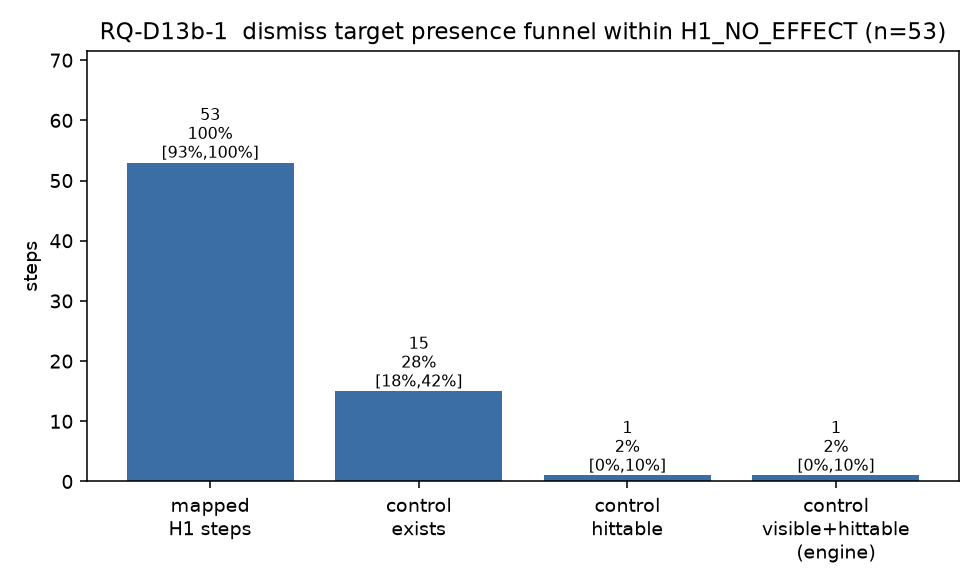

RQ_D13b12_pixel_vs_control.png


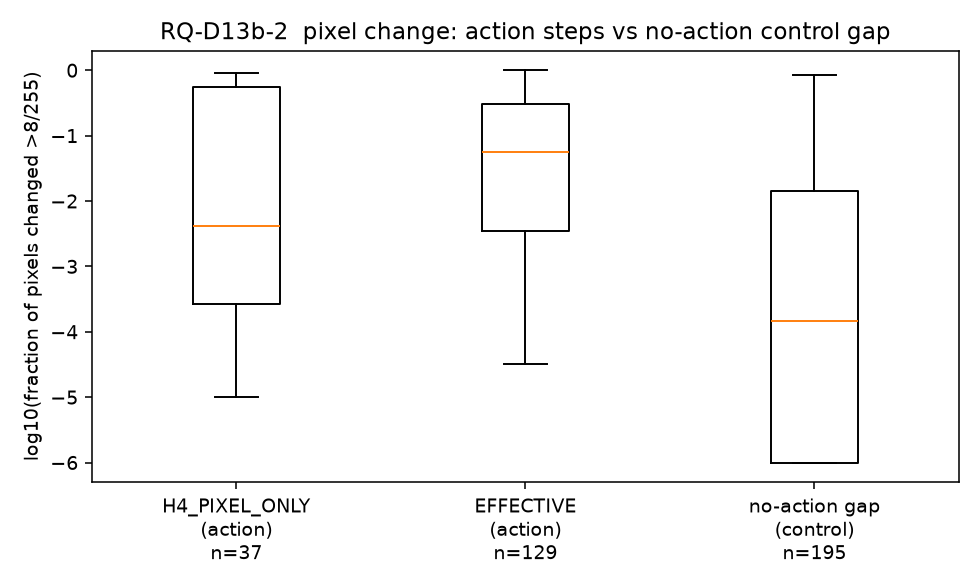

RQ_D13b12_dom_criteria_sensitivity.png


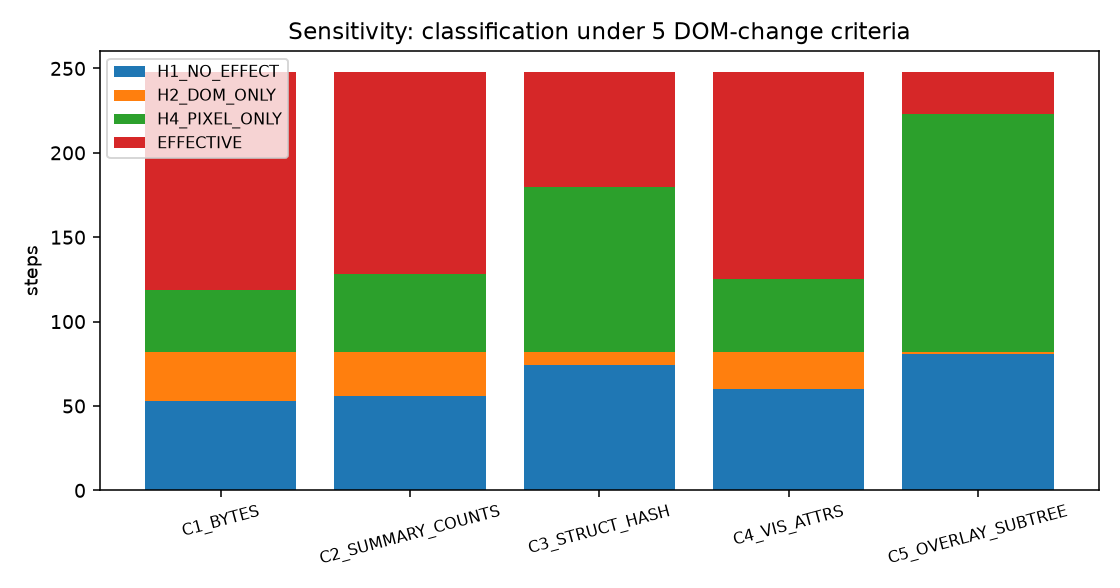

In [20]:
from IPython.display import Image, display
for f in SAVED["figures"]:
    print(Path(f).name)
    display(Image(filename=f))

## 8. 이 RQ 가 답하지 않는 것 · 한계

**답하지 않는 것**: dismissal 대상이 없는 것이 결함인지 정상인지 — construct 판단이며 **A 의 권한**이다.
D 는 GO/NO_GO·threshold·수정 지시를 내지 않는다.

**가장 무거운 한계 (L1)**: dismiss control 의 존재/가시성/hittable 은 `l0a`(조작 전) probe 로만
잴 수 있다. step *k* 실행 시점의 실시간 상태가 아니다. 다만 engine 자신이 바로 그 l0a probe 로
클릭 대상을 골랐으므로 "engine 이 누를 대상을 가지고 있었는가" 에는 정확한 측정이며,
"그 시점 페이지에 닫기 버튼이 실재했는가" 라는 더 넓은 질문에는 답하지 못한다.

In [21]:
for i, l in enumerate(SAVED["limitation"], 1):
    print(f"{i}. {l}\n")
print("heaviest:", SAVED["heaviest_limitation"])
print("\nnot answered:", SAVED["not_answered_by_this_rq"])
print("\n후속 연구질문:")
for q in SAVED["further_research_questions"]:
    print(" -", q)
print("\n방화벽:", SAVED["firewall"]["note"])
assert SAVED["firewall"]["denied_paths_not_opened"] is True
assert SAVED["firewall"]["labels_produced"] is False
assert SAVED["firewall"]["production_modified"] is False

1. L1 probe 시점 불일치 — dismiss control 의 존재/가시성/hittable 은 l0a(조작 전) 시점 probe 로만 잴 수 있다. step k 가 실행될 때의 실시간 상태가 아니다. 다만 engine 자신이 바로 그 l0a probe 로 클릭 대상을 골랐으므로, 'engine 이 누를 대상을 가지고 있었는가' 라는 질문에는 정확히 맞는 측정이다.

2. L2 before-DOM 대용 — l0c 에 dom_before 슬롯이 없다. step k 의 before DOM 을 step k-1 의 dom_after.html(첫 step 은 l0a/dom.html)로 대용했다. 첫 step 은 l0a 캡처와 사이에 ax/css/screenshot/probe 가 끼어 시간 간격이 크다.

3. L3 정적 DOM 에서는 layout 을 계산할 수 없다 — overlay/control 의 존재는 selector 질의로 재확인했지만 visible/hittable 은 재확인하지 못했다.

4. L4 selector 재질의의 모호성 — probe 의 selector 는 최대 8단계 상대경로라 문서 내 여러 곳에 매칭될 수 있다(match_n 을 병기했다).

5. L5 iframe 내부 문서·shadow DOM·canvas·video 프레임은 page.content() 에 담기지 않는다. 이 영역의 변화는 어떤 DOM 기준으로도 볼 수 없다.

6. L6 dismissal 시도의 예외(클릭 timeout 등)는 정적으로 알 수 없다. engine_method 는 '의도된 경로' 이며 실제 실행 결과가 아니다.

7. L7 n=60 관측 · 50 target 규모다. 비율의 정밀도가 낮고 target 단위 결론은 특히 약하다.

heaviest: L1

not answered: 이 RQ 는 dismissal 이 **접근성 관점에서 성공이어야 했는가** 를 답하지 않는다 — 무대상이 결함인지 정상인지는 construct 판단이며 A 의 권한이다.

후속 연구질